# 3. Workspaces, simulations and the Gaussian covariance

A power-spectrum analysis needs error bars. This notebook

1. computes the coupling matrix **once** and reuses it for 200 simulations,
2. saves and reloads a workspace,
3. computes the analytic **Gaussian covariance** of the bandpowers (Garcia-Garcia et al. 2019, the
   method NaMaster implements) and checks it against the scatter of the simulations,
4. checks that the $\chi^2$ of the simulations follows the expected distribution.

In [1]:
import os
os.environ.setdefault("JAX_ENABLE_X64", "1")   # NaMaster-level double precision; set before importing JAX

import time
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import jax
import gmaster as nmt

print("GMaster", nmt.__version__, "| JAX", jax.__version__, "| device:", jax.devices()[0].device_kind)

GMaster 1.0.0 | JAX 0.10.0 | device: NVIDIA RTX PRO 6000 Blackwell Workstation Edition


In [2]:
import camb

def camb_spectra(lmax, r=0.0):
    """Lensed CMB C_ell in muK^2 (TT, EE, BB, TE) for a Planck-2018-like cosmology, ell = 0..lmax."""
    pars = camb.set_params(H0=67.4, ombh2=0.0224, omch2=0.120, mnu=0.06, omk=0, tau=0.054,
                           As=2.1e-9, ns=0.965, r=r, lmax=lmax + 500, WantTensors=r > 0)
    res = camb.get_results(pars)
    cl = res.get_cmb_power_spectra(pars, CMB_unit="muK", raw_cl=True, lmax=lmax)["total"]
    return {k: cl[:, i] for i, k in enumerate(["TT", "EE", "BB", "TE"])}

nside = 256
lmax = 3 * nside - 1
cl_tt = camb_spectra(lmax)["TT"]

theta, phi = hp.pix2ang(nside, np.arange(hp.nside2npix(nside)))
binary = (np.abs(90.0 - np.degrees(theta)) > 25.0).astype(float)
mask = np.asarray(nmt.mask_apodization(binary, 2.0, apotype="C1"))
bins = nmt.NmtBin.from_nside_linear(nside, 24)
ell_eff = np.asarray(bins.get_effective_ells())
keep = ell_eff < 2 * nside          # HEALPix quadrature is accurate below ~2 nside: fit only these
print(f"f_sky = {mask.mean():.3f}, {bins.get_n_bands()} bandpowers, {keep.sum()} below 2 nside")

f_sky = 0.562, 31 bandpowers, 21 below 2 nside


## The coupling matrix is computed once

The workspace depends only on the masks (and the binning). A field only carries one map's
harmonic coefficients. A simulation loop therefore builds a new field per map and reuses the
workspace.

In [3]:
def field_from_seed(seed):
    np.random.seed(seed)
    return nmt.NmtField(mask, [hp.synfast(cl_tt, nside, lmax=lmax, new=True)])

f0 = field_from_seed(0)
workspace = nmt.NmtWorkspace.from_fields(f0, f0, bins)

n_sims = 200
cls = []
t0 = time.perf_counter()
for seed in range(n_sims):
    f = field_from_seed(seed)
    cls.append(np.asarray(workspace.decouple_cell(nmt.compute_coupled_cell(f, f)))[0])
cls = np.array(cls)
elapsed = time.perf_counter() - t0
print(f"{n_sims} simulations in {elapsed:.1f} s ({1e3 * elapsed / n_sims:.0f} ms each, "
      "including the healpy map synthesis on the CPU)")

200 simulations in 3.8 s (19 ms each, including the healpy map synthesis on the CPU)


### Saving a workspace

Coupling matrices of large masks are expensive, so NaMaster can write them to disk. GMaster uses
the same FITS format, so a workspace file can be exchanged with NaMaster.

In [4]:
import tempfile
path = os.path.join(tempfile.mkdtemp(), "workspace_tt.fits")
workspace.write_to(path)
reloaded = nmt.NmtWorkspace.from_file(path)
same = np.allclose(np.asarray(reloaded.get_coupling_matrix()), np.asarray(workspace.get_coupling_matrix()))
print(f"wrote {os.path.getsize(path) / 1e6:.1f} MB; reloaded coupling matrix identical: {same}")

wrote 4.8 MB; reloaded coupling matrix identical: True


## Gaussian covariance

`NmtCovarianceWorkspace.from_fields(fa1, fa2, fb1, fb2)` computes the mode-coupling coefficients
of the covariance (they depend on the masks only), and `gaussian_covariance` combines them with
the spectra of the fields. We use the input theory spectrum here. On data one would use a smooth
fit to the measured spectrum, including noise.

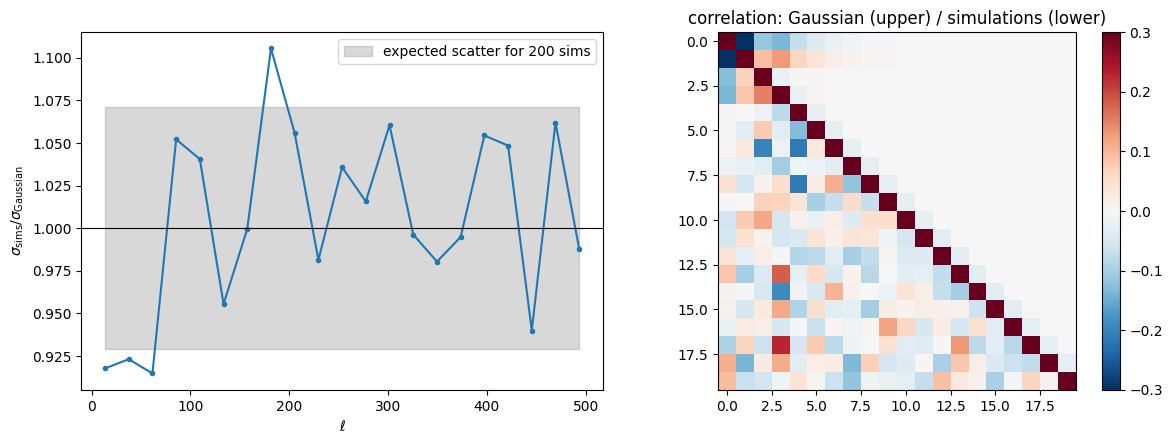

In [5]:
cov_workspace = nmt.NmtCovarianceWorkspace.from_fields(f0, f0, f0, f0)
cov_gauss = np.asarray(nmt.gaussian_covariance(cov_workspace, 0, 0, 0, 0,
                                               [cl_tt], [cl_tt], [cl_tt], [cl_tt], workspace))
cov_sims = np.cov(cls.T)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(ell_eff[keep], np.sqrt(np.diag(cov_sims) / np.diag(cov_gauss))[keep], "o-", ms=3)
ax1.axhline(1, color="k", lw=0.8)
band = np.sqrt(1 / (n_sims - 1))
ax1.fill_between(ell_eff[keep], 1 - band, 1 + band, color="gray", alpha=0.3, label=r"expected scatter for 200 sims")
ax1.set_xlabel(r"$\ell$"); ax1.set_ylabel(r"$\sigma_{\rm sims} / \sigma_{\rm Gaussian}$"); ax1.legend()

def corr(c):
    d = np.sqrt(np.diag(c))
    return c / np.outer(d, d)

n = 20
image = np.triu(corr(cov_gauss)[:n, :n]) + np.tril(corr(cov_sims)[:n, :n], -1)
im = ax2.imshow(image, cmap="RdBu_r", vmin=-0.3, vmax=0.3)
ax2.set_title("correlation: Gaussian (upper) / simulations (lower)")
plt.colorbar(im, ax=ax2)
plt.tight_layout()

The analytic error bars agree with the simulations to within the Monte Carlo noise, and the
neighbouring-bin correlations induced by the mask are reproduced.

## $\chi^2$ test

If the covariance is right, $\chi^2 = (\hat C - C^{\rm th})^T\,\Sigma^{-1}\,(\hat C - C^{\rm th})$
of each simulation follows a $\chi^2$ distribution with as many degrees of freedom as bandpowers
(here the bandpowers below $2N_{\rm side}$).

mean chi2 = 21.7 (expected 21); KS p-value = 0.28


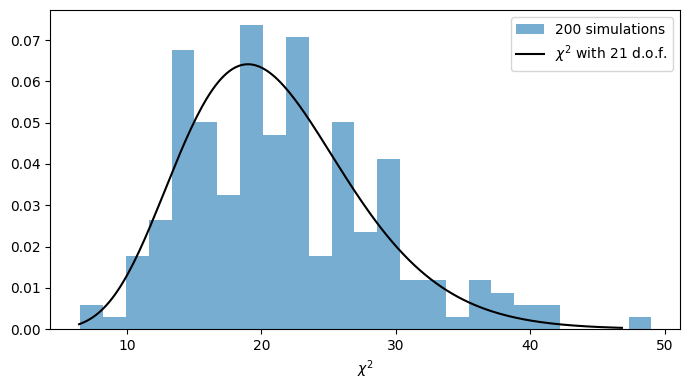

In [6]:
from scipy import stats

windows = np.asarray(workspace.get_bandpower_windows())[0, :, 0, :]
theory_binned = windows @ cl_tt
icov = np.linalg.inv(cov_gauss[np.ix_(keep, keep)])
resid = (cls - theory_binned)[:, keep]
chi2 = np.einsum("si,ij,sj->s", resid, icov, resid)
dof = int(keep.sum())

x = np.linspace(stats.chi2.ppf(0.001, dof), stats.chi2.ppf(0.999, dof), 200)
plt.figure(figsize=(7, 4))
plt.hist(chi2, bins=25, density=True, alpha=0.6, label="200 simulations")
plt.plot(x, stats.chi2.pdf(x, dof), "k-", label=rf"$\chi^2$ with {dof} d.o.f.")
plt.xlabel(r"$\chi^2$"); plt.legend(); plt.tight_layout()
print(f"mean chi2 = {chi2.mean():.1f} (expected {dof}); KS p-value = {stats.kstest(chi2, 'chi2', args=(dof,)).pvalue:.2f}")